# STEP 1: load the data

In [75]:
import pandas as pd
import numpy as np

In [76]:
df = pd.read_csv("powerplant_data.csv")

In [77]:
df.head()
# AT - temperature
# V - vacuum
# AP - pressure
# RH - humidity

# PE - produced energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [78]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [79]:
X = df.drop("PE", axis=1)
y = df["PE"]

y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [80]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [81]:
df.shape

(9568, 5)

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 2: Data conversion to Tensor

In [ ]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

# why use .values & .view
#  if input is not in numpy array like y_train (its dtype is pandas Series therfore need to use .values) but X_train_scaled is in numpy array therefore no need to use .values
# .view(rows,cols): abhi shape of y_train is (n,) 1D: { [1,2,3,4] } but pytorch want tensors in the 
# shape (n,1) 
# [ [1],
#   [2],
#   [3],
#   [4],] there here .view(-1,1) will be replaced by .view(765, 1 )

x_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

print(type(X_train_tensor))
print(type(y_train_tensor))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [84]:
print(type(y_train))
print(y_train.shape)

<class 'pandas.core.series.Series'>
(7654,)


In [85]:
# TensorDataset & DataLoader

In [86]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [87]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

DEEP LEARNING
# step4: DEFINE ANN model

In [88]:
# Define our ann model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        # self is reffering to our class object
        self.model = nn.Sequential(
            # now sequentially define layer
            # 1st hidden layer
            # nn.Linear(in_features, out_features)
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1)
    )
    
    # logic of forward propagation (need to write on our our if using pytorch)
    def forward(self, x):
        return self.model(x)
    
    # in pytorch no need to define back propagation

In [89]:
import torch.optim as optim

model = ANN()

# loss, optimizer
# since this is regression we'll use mse for calcualting loss
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters()) 

# STEP5: Train the model

In [90]:
# train the ANN

epochs = 100
train_losses = []
val_losses= []
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # save the total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad() # clear previously accumulated gradients before computing new ones

        outputs = model(xb) # predicted outputs of this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop. compute gradients (how wrong we are)
        optimizer.step() # params update (adjust weight a bit)

        # running loss -> loss of for all bathces
        running_loss += loss.item() # loss is a tensor value => convert in py float value\

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad(): # qnoo gradients compute : here we telling pytorch not to calculate gradients bcs pytoch has autograd which automatically compute gradients
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            # in testing we do not need back propagation ( no need to update weights ) 
            running_val_loss += loss.item()
        
        epoch_val_loss = running_val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

        print(f"epoch {epoch+1}/{epochs} ===> training loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "best_model.pt") # .pt or .pth




epoch 1/100 ==> train loss = 205272.7298828125 & val loss = 202025.50703125
epoch 1/100 ===> training loss = 205272.7298828125 & val loss = 202025.50703125
epoch 2/100 ==> train loss = 191470.26393229168 & val loss = 175104.09010416668
epoch 2/100 ===> training loss = 191470.26393229168 & val loss = 175104.09010416668
epoch 3/100 ==> train loss = 149017.0994466146 & val loss = 118805.710546875
epoch 3/100 ===> training loss = 149017.0994466146 & val loss = 118805.710546875
epoch 4/100 ==> train loss = 87811.75864257812 & val loss = 59390.61764322917
epoch 4/100 ===> training loss = 87811.75864257812 & val loss = 59390.61764322917
epoch 5/100 ==> train loss = 41065.04356282552 & val loss = 28400.321028645834
epoch 5/100 ===> training loss = 41065.04356282552 & val loss = 28400.321028645834
epoch 6/100 ==> train loss = 23183.633573404946 & val loss = 19766.53859049479
epoch 6/100 ===> training loss = 23183.633573404946 & val loss = 19766.53859049479
epoch 7/100 ==> train loss = 17807.216

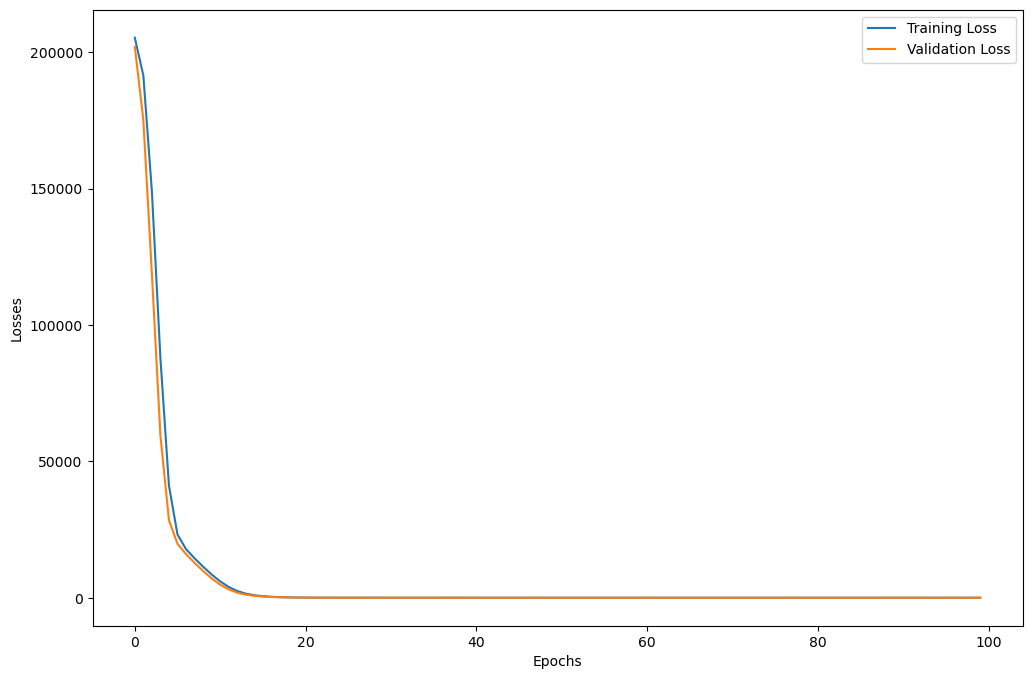

In [91]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training loss": train_losses,
    "Validation loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training loss"], label = 'Training Loss')
plt.plot(loss_df["Validation loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

SAVING & LOADING BEST MODEL

best model is saved that means best models parameters are stored in a file
# learnable params(w,b) => best model : loss minimum

# training loss : loss minimum on seen data 
# validation loss : loss minimum on unseen data
# validation loss should be preferred

In [92]:
# loading the best part
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

# STEP 6- EVALUATION

In [94]:
# EVALUATE
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(x_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())

Training MSE:  20.610685348510742
Testing MSE:  18.781476974487305


In [95]:
from sklearn.metrics import r2_score

print("r2 score: ", r2_score(y_test, test_preds))

r2 score:  0.9343635851342912


In [ ]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df =  pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis = 1)